# Paper‑ready simulations: multivariate calibration via preranks

This notebook reproduces paper‑ready simulation figures and redundancy analysis for multivariate calibration diagnostics based on preranks.

**Key outputs:**
- Full prerank reliability grids for each misspecification.
- Redundancy (Spearman) heatmaps per case.
- Average redundancy table across cases.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from scipy.stats import spearmanr
from torch.distributions import MultivariateNormal

from moc.metrics.distribution_metrics import calculate_PIT, pce

sns.set_context("paper")
plt.rcParams["figure.dpi"] = 120

## Simulation design (Thorarinsdottir & Schuhen‑style)

We use a multivariate Gaussian with
\(\Sigma_{ij} = \sigma^2 \exp(-|i-j|/\tau)\), with **true** parameters
\(d=10, \sigma^2=1, \tau=1\). Predicted distributions are misspecified by
mean, variance, or correlation (\(\tau\)).

In [2]:
np.random.seed(7)
torch.manual_seed(7)

# True parameters
D = 10
sigma2_true = 1.0
tau_true = 1.0
mu_true = np.zeros(D)


def exp_decay_cov(d, sigma2, tau):
    idx = np.arange(d)
    dist = np.abs(idx[:, None] - idx[None, :])
    return sigma2 * np.exp(-dist / tau)


cov_true = exp_decay_cov(D, sigma2_true, tau_true)

# Misspecification cases
mu_under = np.full(D, -0.5)
mu_over = np.full(D, 0.5)

cases = [
    {"name": "Under‑estimation of mean", "mu": mu_under, "sigma2": sigma2_true, "tau": tau_true},
    {"name": "Over‑estimation of mean",  "mu": mu_over,  "sigma2": sigma2_true, "tau": tau_true},
    {"name": "Under‑estimation of variance", "mu": mu_true, "sigma2": 0.85, "tau": tau_true},
    {"name": "Over‑estimation of variance",  "mu": mu_true, "sigma2": 1.25, "tau": tau_true},
    {"name": "Under‑estimation of correlation", "mu": mu_true, "sigma2": sigma2_true, "tau": 0.5},
    {"name": "Over‑estimation of correlation",  "mu": mu_true, "sigma2": sigma2_true, "tau": 2.0},
]

for c in cases:
    c["cov"] = exp_decay_cov(D, c["sigma2"], c["tau"])

# Data
N_sim = 3000
GT = np.random.multivariate_normal(mu_true, cov_true, size=N_sim)
y_t = torch.tensor(GT, dtype=torch.float32)

# Batch predictive distributions per case
case_dists = []
for c in cases:
    dist_pred = MultivariateNormal(
        loc=torch.tensor(c["mu"], dtype=torch.float32).repeat(N_sim, 1),
        covariance_matrix=torch.tensor(c["cov"], dtype=torch.float32).expand(N_sim, D, D)
    )
    case_dists.append(dist_pred)

print("GT shape:", GT.shape)
print("Pred batch shape:", case_dists[0].mean.shape)


GT shape: (3000, 10)
Pred batch shape: torch.Size([3000, 10])


## Prerank reliability grids (all preranks per case)

Each figure shows: **true vs predicted scatter**, then PIT reliability for
`marginal`, `mean`, `variance`, `dependency`, `pca`, `density`, `cdf`.

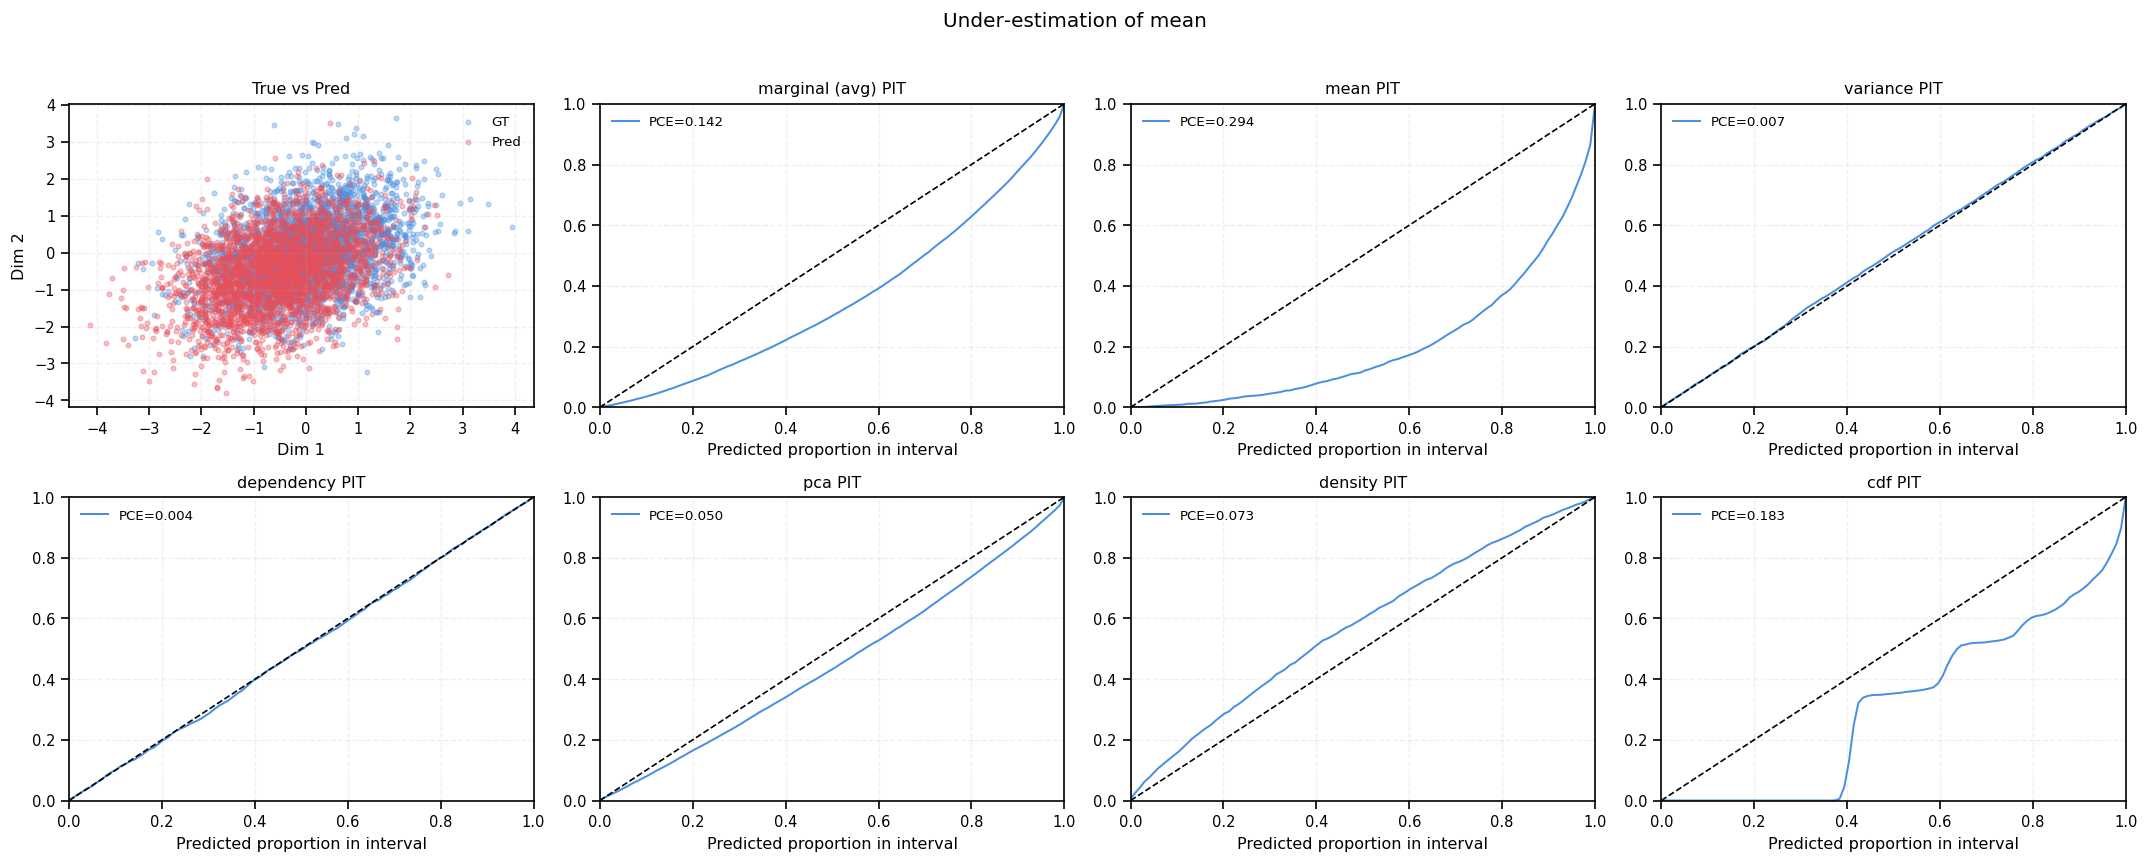

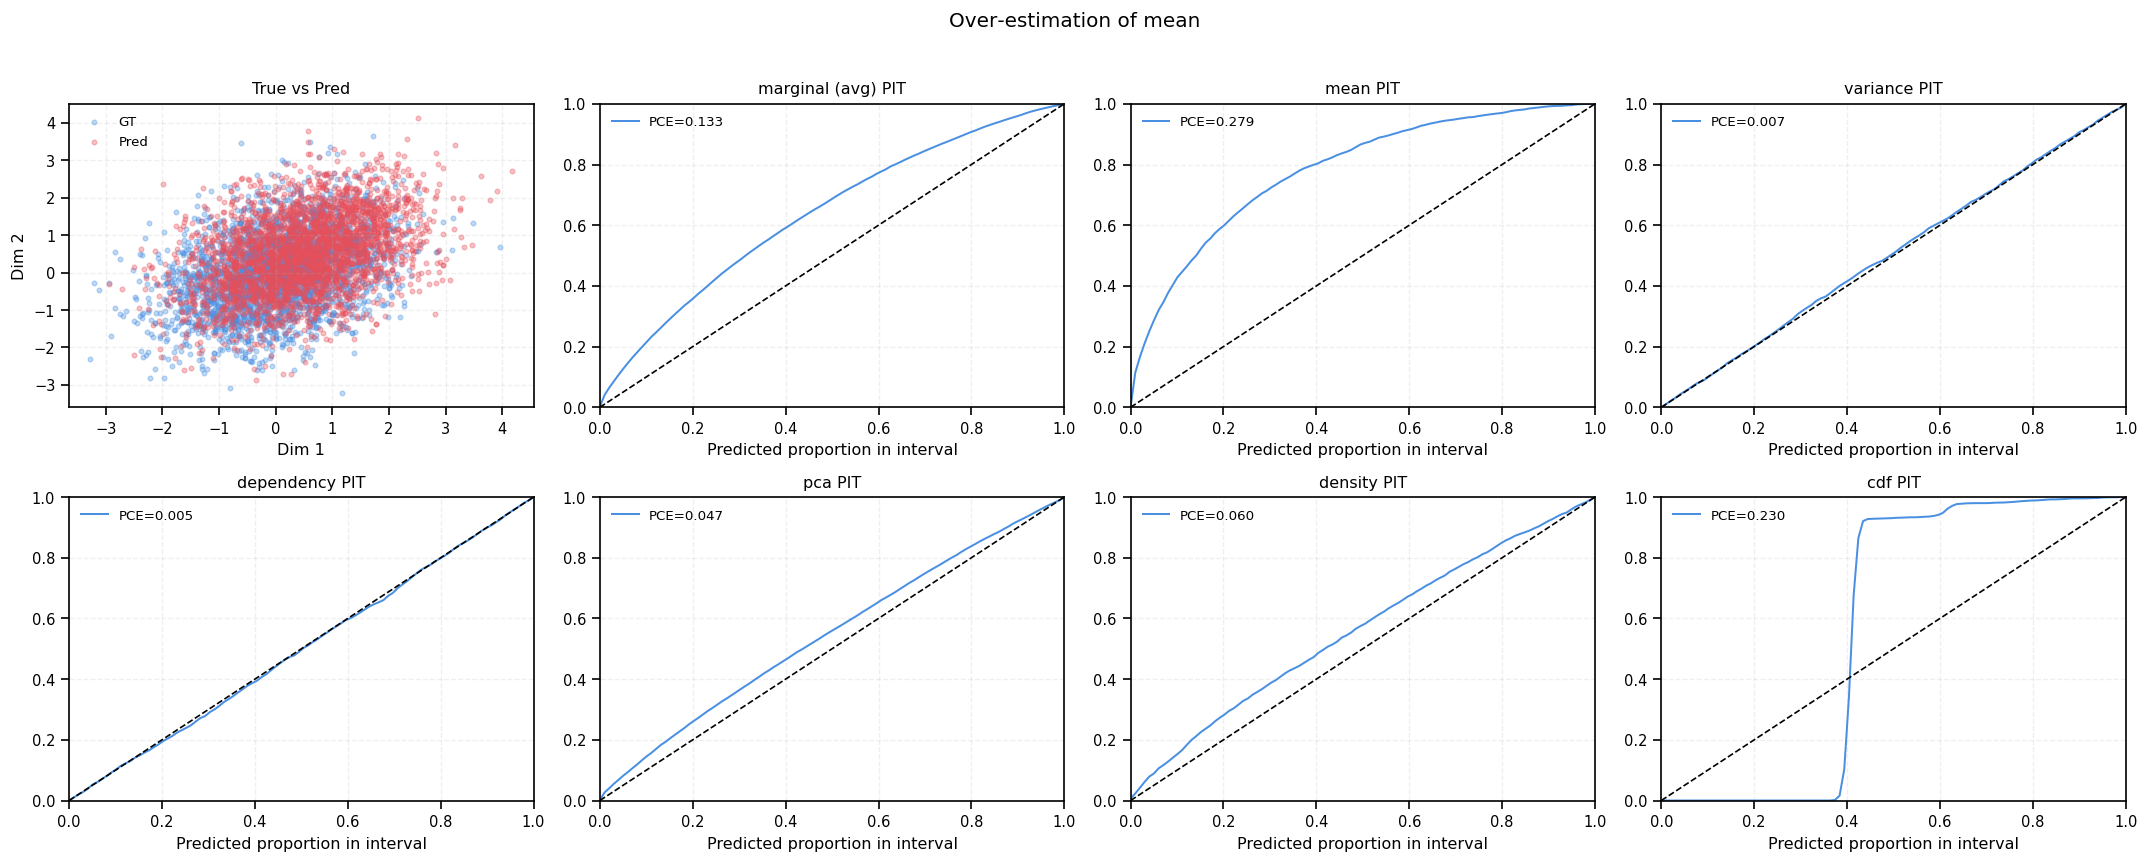

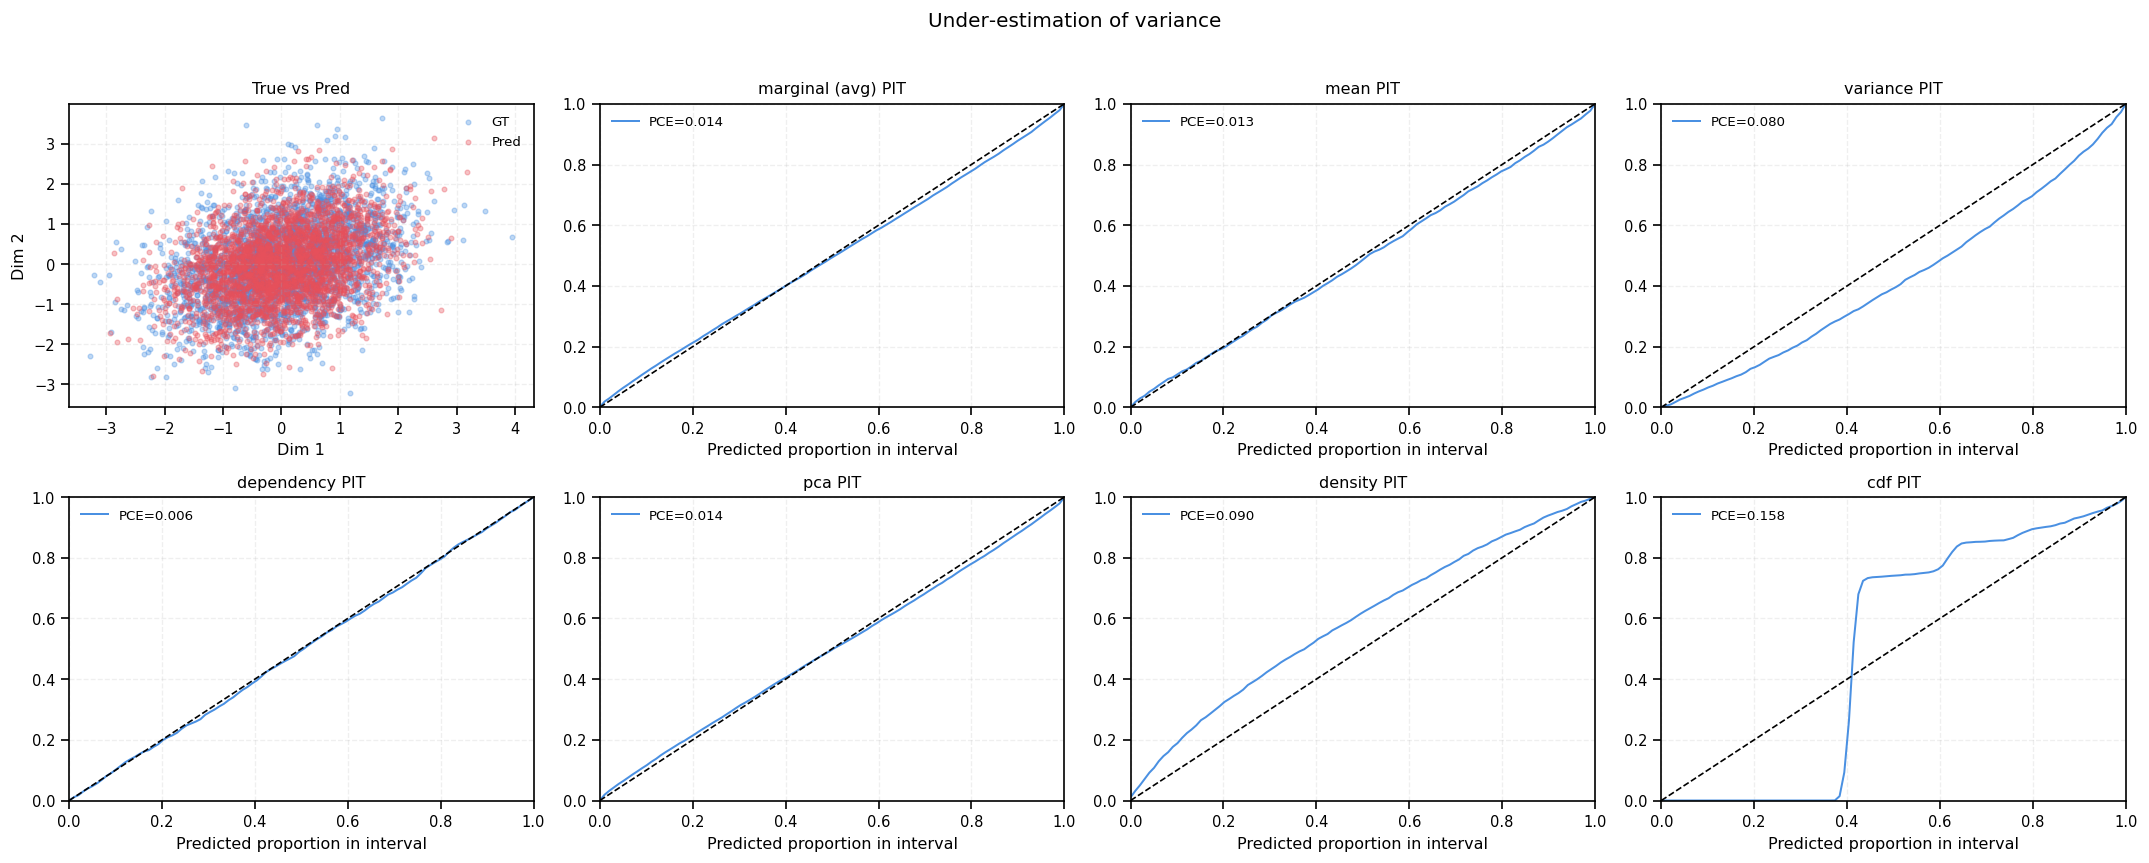

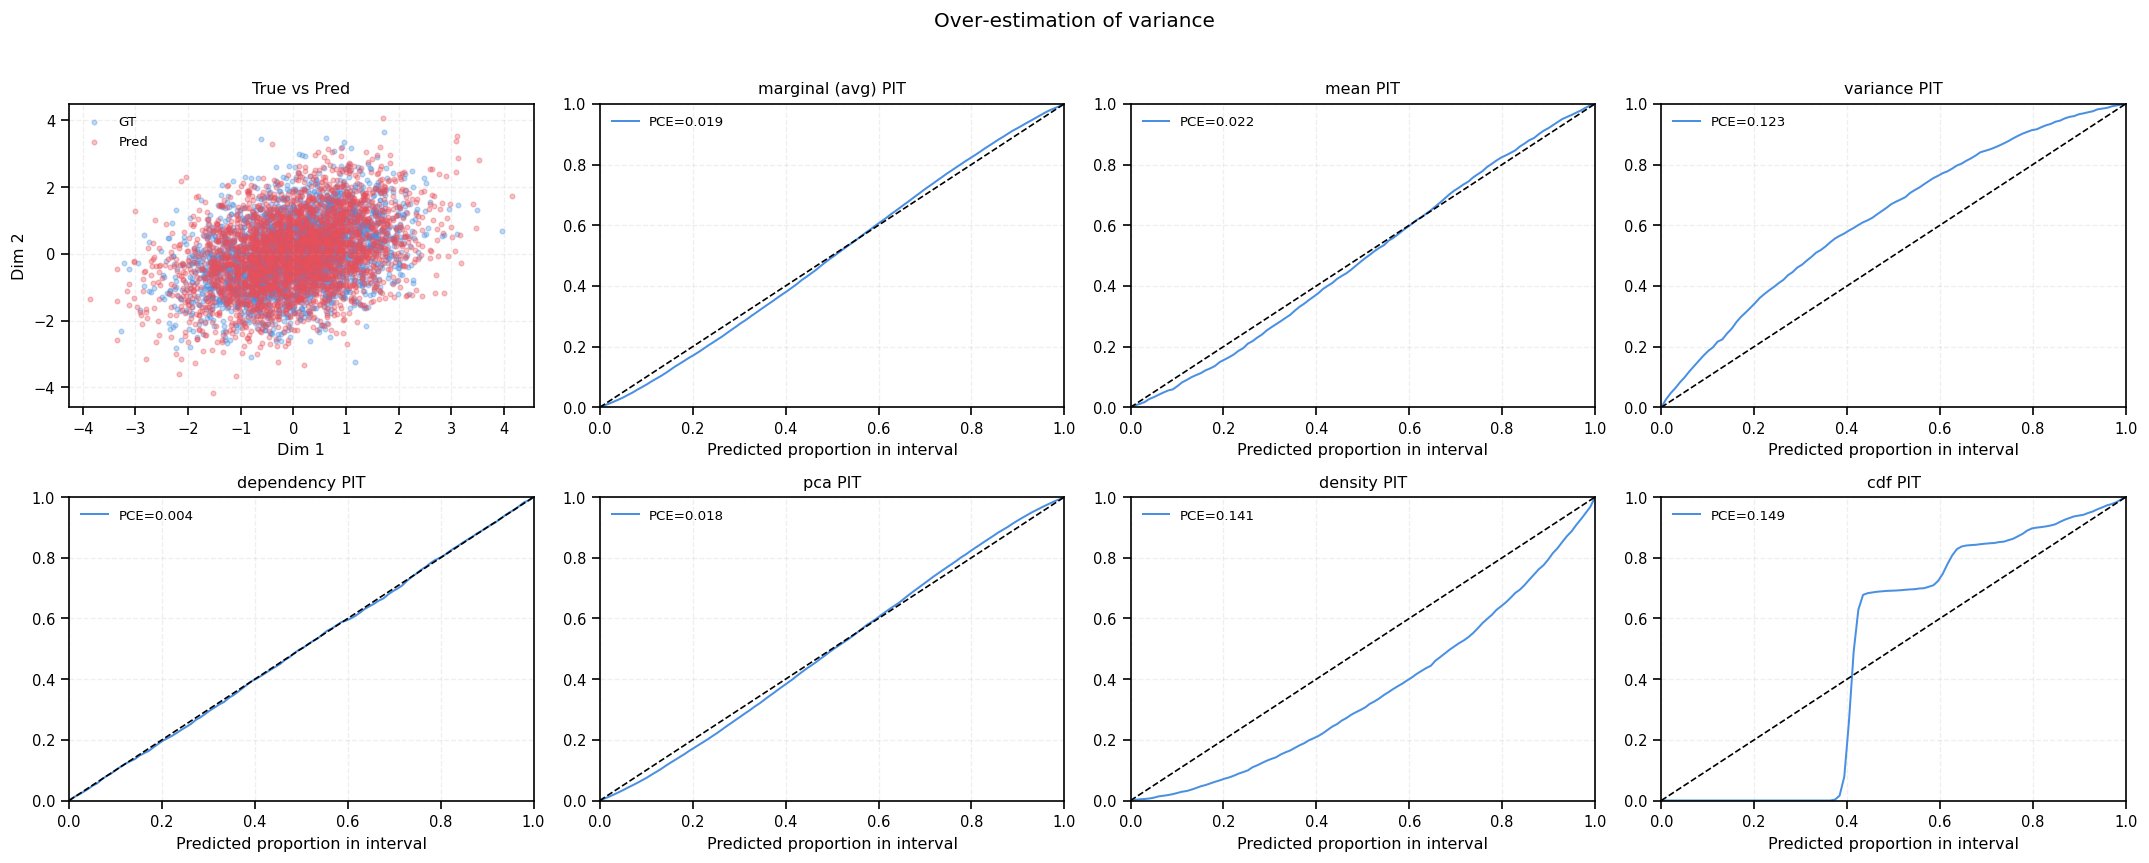

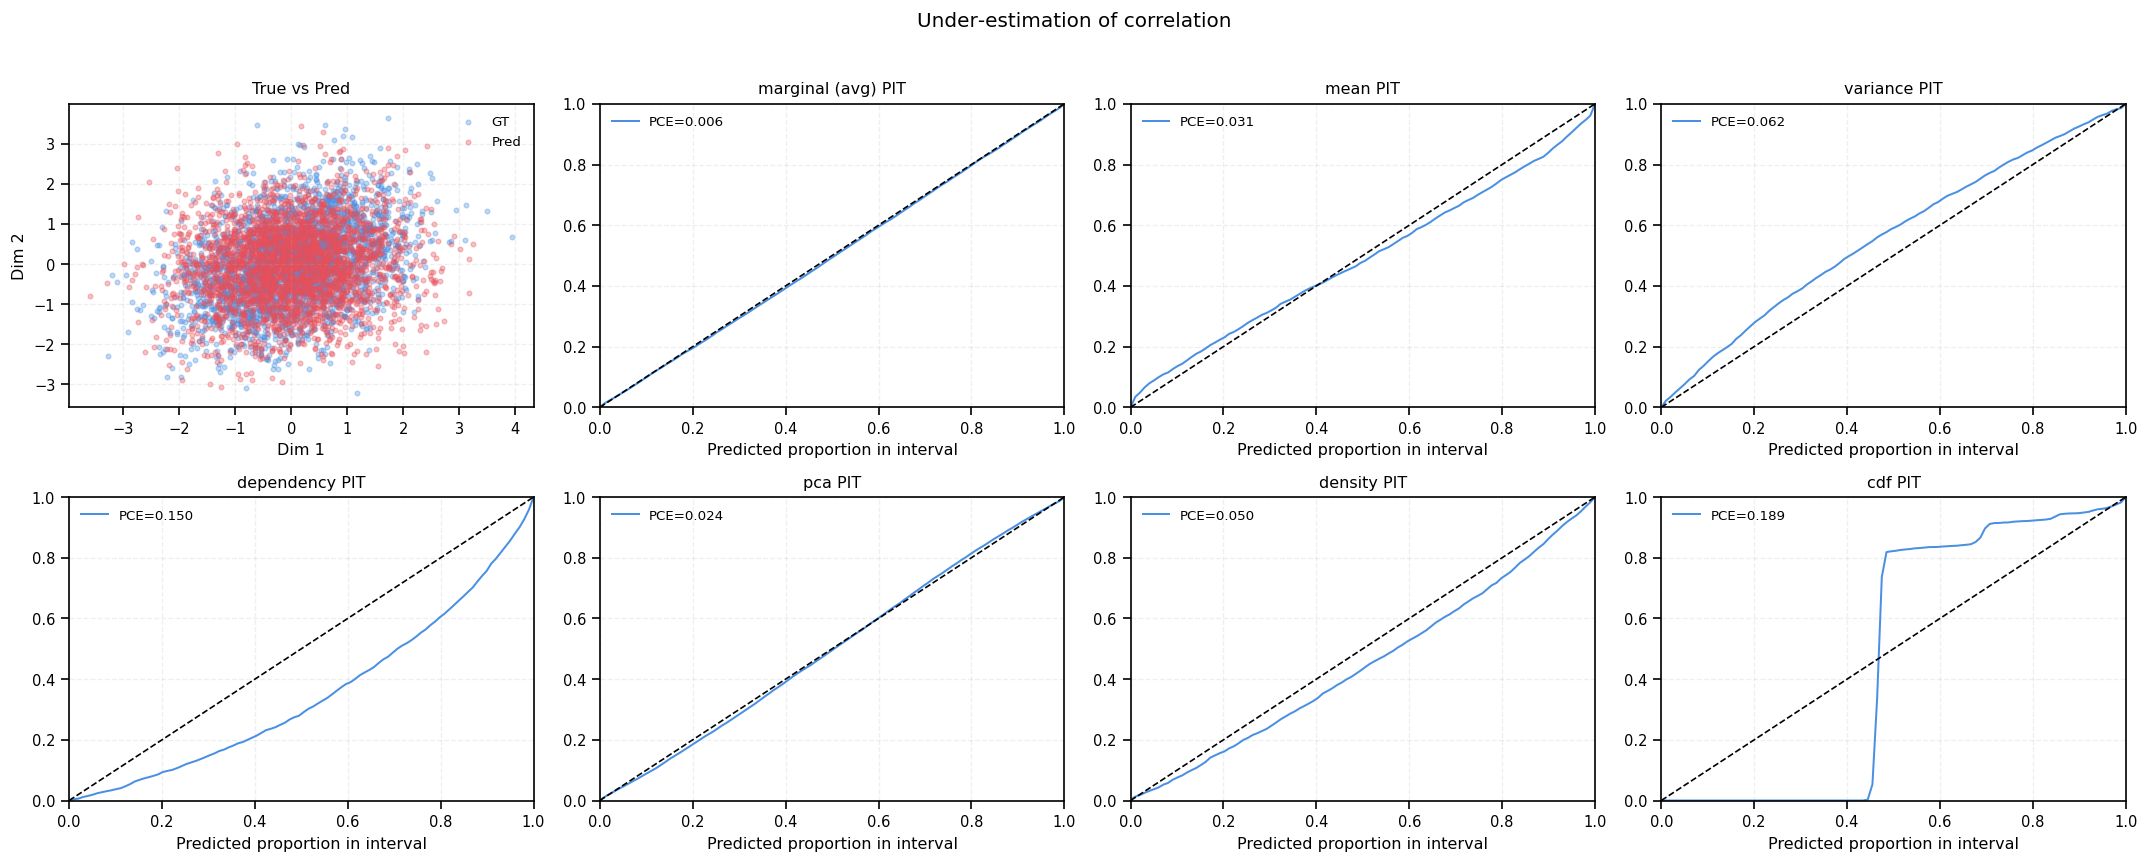

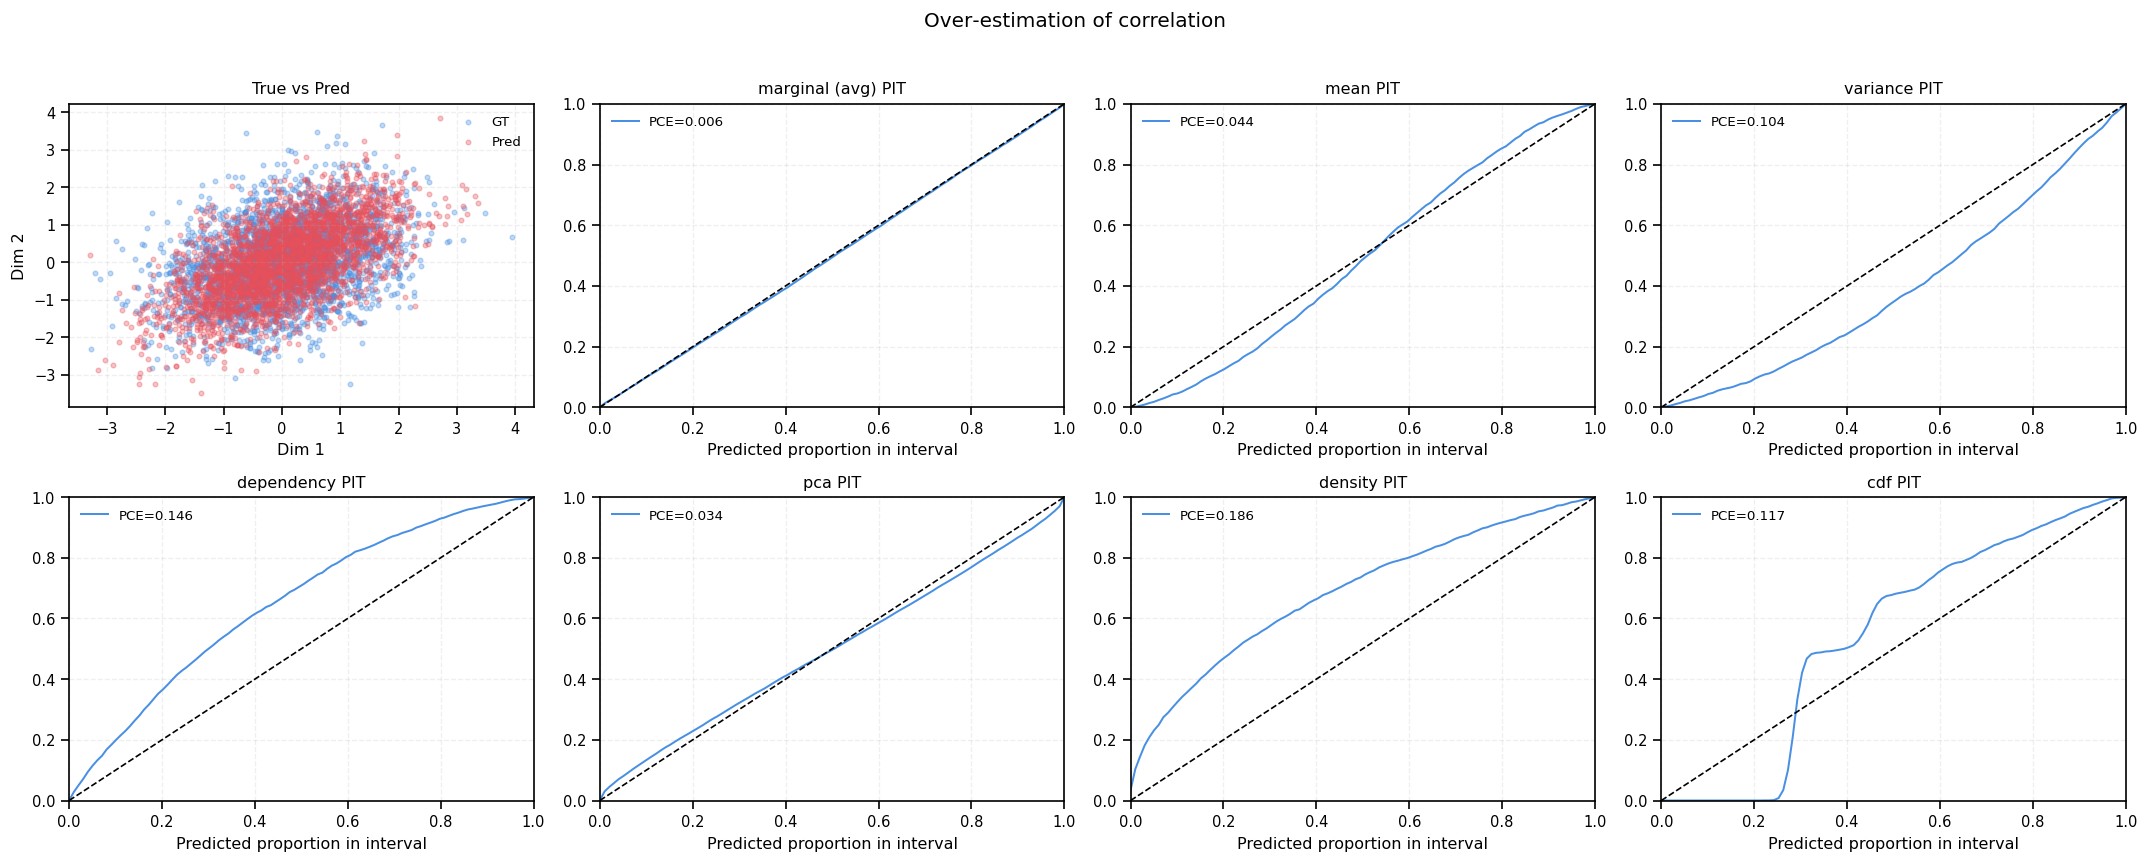

In [3]:
alphas = torch.linspace(0, 1, 100).cpu().numpy()


def _plot_reliability(ax, cdf, pce, title, color='#4A90E2'):
    ax.plot(alphas, cdf, color=color, label=f'PCE={pce:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(title)
    ax.set_xlabel('Predicted proportion in interval')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.2, linestyle='--')
    ax.legend(frameon=False, fontsize=8)


def _mean_cdf_and_pce(cdfs, pces):
    cdf_mean = cdfs.mean(dim=0).cpu().numpy()
    pce_mean = float(pces.mean())
    return cdf_mean, pce_mean


def plot_prerank_grid(case_name, dist_pred_batch, n_samples=200):
    fig, axs = plt.subplots(2, 4, figsize=(18, 7))

    # True vs predicted distribution (sample from batch MVN)
    pred_samples = dist_pred_batch.sample().cpu().numpy()  # (N_sim, D)
    axs[0, 0].scatter(GT[:, 0], GT[:, 1], s=8, alpha=0.35, label='GT', color='#4A90E2')
    axs[0, 0].scatter(pred_samples[:, 0], pred_samples[:, 1], s=8, alpha=0.35, label='Pred', color='#E8505B')
    axs[0, 0].set_title('True vs Pred')
    axs[0, 0].set_xlabel('Dim 1'); axs[0, 0].set_ylabel('Dim 2')
    axs[0, 0].legend(frameon=False, fontsize=8)
    axs[0, 0].grid(alpha=0.2, linestyle='--')

    # Marginal (average over dims)
    pce_marg, cdfs_marg = pce(dist_pred_batch, y_t, n_samples=n_samples, prerank='marginal', setup='real')
    cdf_marg, pce_m = _mean_cdf_and_pce(cdfs_marg, pce_marg)
    _plot_reliability(axs[0, 1], cdf_marg, pce_m, 'marginal (avg) PIT')

    # Mean / variance / dependency
    for ax, pr in [(axs[0, 2], 'mean'), (axs[0, 3], 'variance'), (axs[1, 0], 'dependency')]:
        pce_pr, cdfs_pr = pce(dist_pred_batch, y_t, n_samples=n_samples, prerank=pr, setup='real')
        cdf_pr, pce_pr_mean = _mean_cdf_and_pce(cdfs_pr, pce_pr)
        _plot_reliability(ax, cdf_pr, pce_pr_mean, f'{pr} PIT')

    # PCA / density / CDF
    for ax, pr in [(axs[1, 1], 'pca'), (axs[1, 2], 'density'), (axs[1, 3], 'cdf')]:
        pce_pr, cdfs_pr = pce(dist_pred_batch, y_t, n_samples=n_samples, prerank=pr, setup='real')
        cdf_pr, pce_pr_mean = _mean_cdf_and_pce(cdfs_pr, pce_pr)
        _plot_reliability(ax, cdf_pr, pce_pr_mean, f'{pr} PIT')

    fig.suptitle(case_name, y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()


for c, dist_pred in zip(cases, case_dists):
    plot_prerank_grid(c['name'], dist_pred, n_samples=200)

## Redundancy analysis between preranks

We compute Spearman correlations between prerank PIT vectors to assess
redundancy and complementarity.

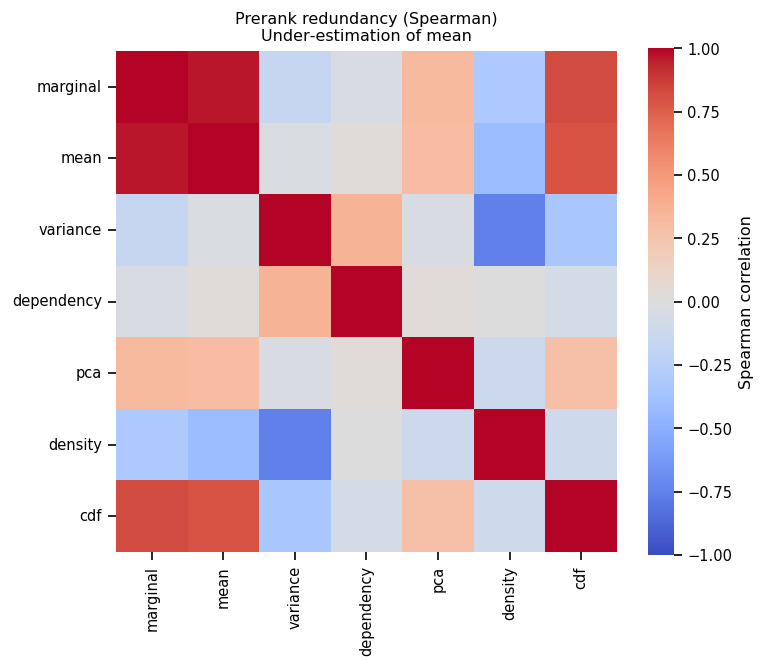

KeyboardInterrupt: 

In [ ]:
prerank_list = ['marginal', 'mean', 'variance', 'dependency', 'pca', 'density', 'cdf']


def _pit_vector(dist_pred_batch, y_t, prerank, n_samples=200):
    pits, _ = calculate_PIT(dist_pred_batch, y_t, n_samples=n_samples, prerank=prerank, setup='real')
    pits = pits.squeeze(-1)  # (n_scores, N)
    pit_vec = pits.mean(dim=0)
    return pit_vec.detach().cpu().numpy()


def plot_prerank_redundancy(case_name, dist_pred_batch, y_t, n_samples=200):
    pit_matrix = []
    for pr in prerank_list:
        pit_matrix.append(_pit_vector(dist_pred_batch, y_t, pr, n_samples=n_samples))
    pit_matrix = np.stack(pit_matrix, axis=1)  # (N, R)

    corr = spearmanr(pit_matrix).correlation  # (R, R)

    plt.figure(figsize=(6.5, 5.5))
    sns.heatmap(
        corr,
        vmin=-1, vmax=1, cmap='coolwarm',
        xticklabels=prerank_list,
        yticklabels=prerank_list,
        square=True,
        cbar_kws={'label': 'Spearman correlation'}
    )
    plt.title(f"Prerank redundancy (Spearman)\n{case_name}")
    plt.tight_layout()
    plt.show()


# for c, dist_pred in zip(cases, case_dists):
#     plot_prerank_redundancy(c['name'], dist_pred, y_t, n_samples=200)

## Average redundancy table (across cases)

Averaging the correlation matrices across all misspecifications yields a single
summary table of prerank relationships.

Average Spearman correlation across cases:


,marginal,mean,variance,dependency,pca,density,cdf
marginal,1.000000,0.975351,-0.039715,0.017506,0.344902,0.025200,0.527664
mean,0.975351,1.000000,-0.031283,0.021736,0.345841,0.017386,0.521051
variance,-0.039715,-0.031283,1.000000,0.353335,-0.012381,-0.814125,-0.223857
dependency,0.017506,0.021736,0.353335,1.000000,0.015090,0.012885,-0.053309
pca,0.344902,0.345841,-0.012381,0.015090,1.000000,0.007150,0.198188
density,0.025200,0.017386,-0.814125,0.012885,0.007150,1.000000,0.090742
cdf,0.527664,0.521051,-0.223857,-0.053309,0.198188,0.090742,1.000000


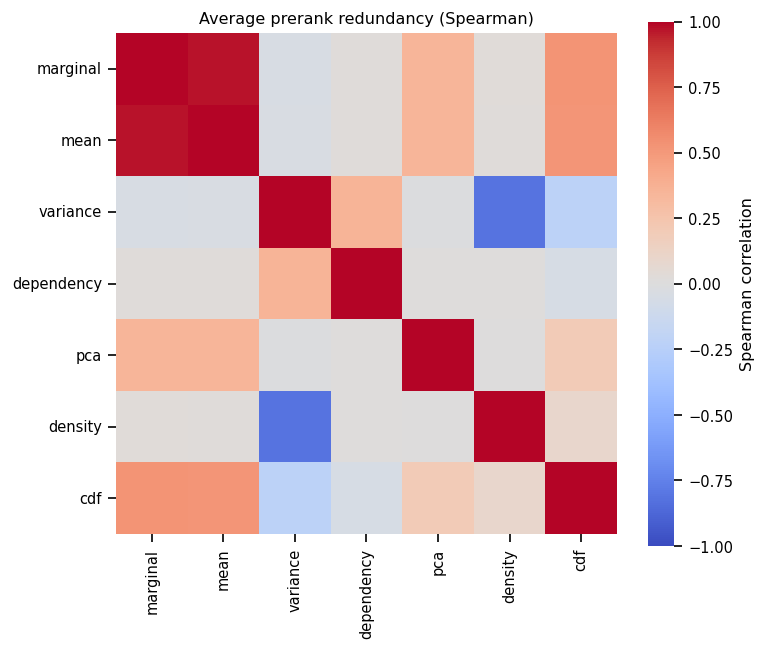

In [ ]:
corr_list = []
for c, dist_pred in zip(cases, case_dists):
    pit_matrix = []
    for pr in prerank_list:
        pit_matrix.append(_pit_vector(dist_pred, y_t, pr, n_samples=200))
    pit_matrix = np.stack(pit_matrix, axis=1)
    corr = spearmanr(pit_matrix).correlation
    corr_list.append(corr)

avg_corr = np.nanmean(np.stack(corr_list, axis=0), axis=0)

avg_corr_df = pd.DataFrame(avg_corr, index=prerank_list, columns=prerank_list)
print("Average Spearman correlation across cases:")
display(avg_corr_df)

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(
    avg_corr,
    vmin=-1, vmax=1, cmap='coolwarm',
    xticklabels=prerank_list,
    yticklabels=prerank_list,
    square=True,
    cbar_kws={'label': 'Spearman correlation'}
)
plt.title("Average prerank redundancy (Spearman)")
plt.tight_layout()
plt.show()